# Random Forest without Feature Selection

Step 1 - Load dataset runtime: 0.12658 seconds
Data types of columns:
url_length        int64
n_dots            int64
n_hypens          int64
n_underline       int64
n_slash           int64
n_questionmark    int64
n_equal           int64
n_at              int64
n_and             int64
n_exclamation     int64
n_space           int64
n_tilde           int64
n_comma           int64
n_plus            int64
n_asterisk        int64
n_hastag          int64
n_dollar          int64
n_percent         int64
n_redirection     int64
phishing          int64
dtype: object
Step 2 - Data preprocessing runtime: 0.01000 seconds
Step 3 - Train-test split runtime: 0.01804 seconds
Before SMOTE: Class distribution in y_train: 0    51017
1    29044
dtype: int64
After SMOTE: Class distribution in y_train_resampled: 0    51017
1    51017
dtype: int64
Step 4 - SMOTE runtime: 14.21921 seconds
Step 5 - Model training runtime: 4.90883 seconds
Accuracy: 0.88854
ROC-AUC: 0.95366
False Positives: 1402
Confusion Matrix

<Figure size 640x480 with 0 Axes>

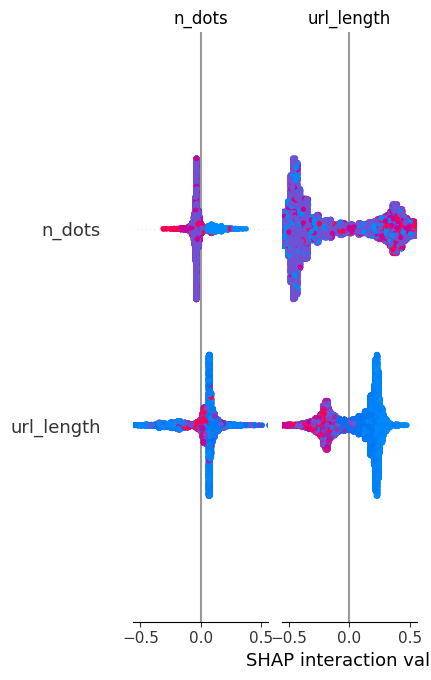

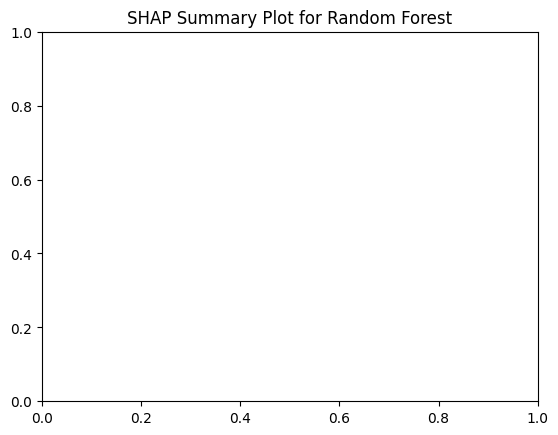

<Figure size 640x480 with 0 Axes>

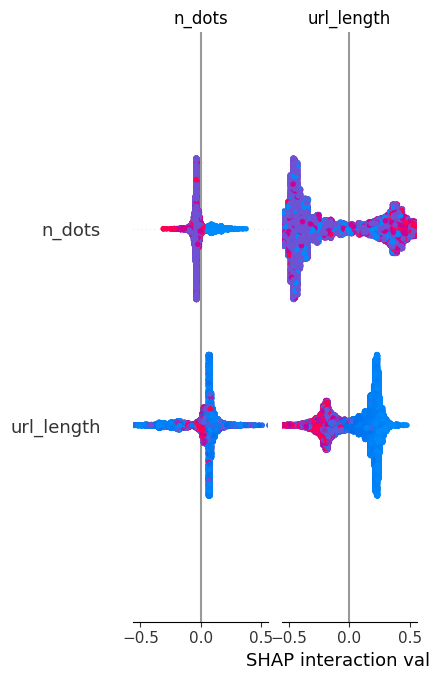

C:\Users\DELL\AppData\Local\Temp\ipykernel_3596\319242819.py:112: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  top_20_feature_names = X.columns[top_20_features]


ValueError: Buffer has wrong number of dimensions (expected 1, got 2)

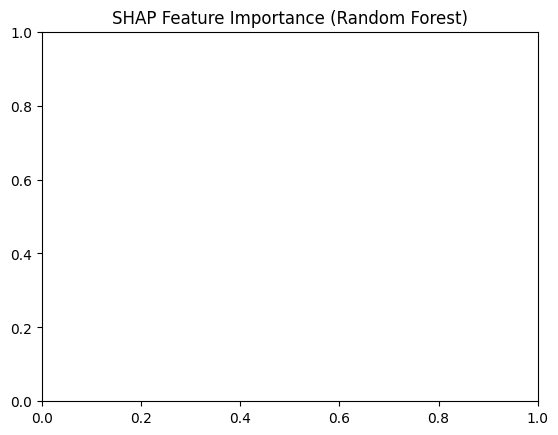

<Figure size 640x480 with 0 Axes>

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Track overall runtime
overall_start_time = time.time()

# Step 1: Load dataset
step_start_time = time.time()
df = pd.read_csv('ds_100k20.csv')
step_end_time = time.time()
print(f"Step 1 - Load dataset runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 2: Data preprocessing
step_start_time = time.time()
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Ensure labels are 0 and 1 for binary classification
y = np.where(y == -1, 0, y)
step_end_time = time.time()
print(f"Step 2 - Data preprocessing runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 3: Train-test split
step_start_time = time.time()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
step_end_time = time.time()
print(f"Step 3 - Train-test split runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 4: Handle imbalance using SMOTE
step_start_time = time.time()
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())
step_end_time = time.time()
print(f"Step 4 - SMOTE runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 5: Train Random Forest model
step_start_time = time.time()
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
step_end_time = time.time()
print(f"Step 5 - Model training runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 6: Predict and evaluate
step_start_time = time.time()
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Extract False Positive from confusion matrix
fp = conf_matrix[0, 1]

print(f"Accuracy: {rf_accuracy:.5f}")
print(f"ROC-AUC: {rf_roc_auc:.5f}")
print(f"False Positives: {fp}")
print("Confusion Matrix:")
print(conf_matrix)
step_end_time = time.time()
print(f"Step 6 - Model evaluation runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 7: SHAP Analysis
step_start_time = time.time()
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Use shap_values[1] for class 1 in binary classification
if isinstance(shap_values, list) and len(shap_values) > 1:
    shap_values = shap_values[1]

# SHAP summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.title("SHAP Summary Plot for Random Forest")

# SHAP feature importance plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar")
plt.title("SHAP Feature Importance (Random Forest)")

# SHAP bee swarm plot for top 20 features
top_20_features = np.argsort(np.abs(shap_values).mean(axis=0))[-20:]
top_20_feature_names = X.columns[top_20_features]
plt.figure()
shap.summary_plot(shap_values[:, top_20_features], X_test.iloc[:, top_20_features], feature_names=top_20_feature_names, plot_type="dot")
plt.title("SHAP Bee Swarm Plot for Top 20 Features")
step_end_time = time.time()
print(f"Step 7 - SHAP analysis runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 8: Add new features to dataset
step_start_time = time.time()
# Add predicted label to the dataset
df['Predicted_Label'] = rf_model.predict(X)

# Add SHAP values as new features
shap_df = pd.DataFrame(shap_values, columns=[f"SHAP_{col}" for col in X.columns])
shap_df.index = df.index
0df = pd.concat([df, shap_df], axis=1)

# Save the enhanced dataset
df.to_csv("enhanced_ds100k20.csv", index=False)
step_end_time = time.time()
print(f"Step 8 - Add features to dataset runtime: {step_end_time - step_start_time:.5f} seconds")

# Step 9: Overall runtime
overall_end_time = time.time()
print(f"Overall runtime: {overall_end_time - overall_start_time:.5f} seconds")


In [18]:
shap.summary_plot(shap_values[:, top_20_features], X_test.iloc[:, top_20_features], feature_names=top_20_feature_names)

ValueError: Buffer has wrong number of dimensions (expected 1, got 2)

In [19]:
# Select top 20 important features based on mean absolute SHAP values
top_20_features = np.argsort(np.abs(shap_values).mean(axis=0))[-20:]  # Indices of top 20 features
top_20_feature_names = X_test.columns[top_20_features]  # Feature names for top 20 features

# Generate SHAP beeswarm plot for the top 20 features
plt.figure()
shap.summary_plot(shap_values[:, top_20_features], X_test.iloc[:, top_20_features], feature_names=top_20_feature_names, plot_type="dot")
plt.title("SHAP Beeswarm Plot (Top 20 Features)")
plt.savefig(f"{dataset_name.split('.')[0]}_{model_name}_SHAP_Beeswarm_Top20.png")
plt.close()


C:\Users\DELL\AppData\Local\Temp\ipykernel_3596\989093724.py:3: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  top_20_feature_names = X_test.columns[top_20_features]  # Feature names for top 20 features


ValueError: Buffer has wrong number of dimensions (expected 1, got 2)

<Figure size 640x480 with 0 Axes>